# Round 2 — Image texture, spatial context, and multiscale representations

**Question:** Can a complete, spatially ordered MRI series yield reproducible contextual representations without corrupting geometry or treating missing views as disease negatives?

**STOP until Round 1 has been reviewed and the one-series download is approved in your next manual milestone.** This notebook does not download images. It requires the complete-series receipt from `scripts/download_image_sample.py`.

**First pilot:** one complete series, 8–96 single-frame slices; 140 per-series candidates, 423 columns in the plane-preserving study schema (unavailable planes remain missing). Zero model fits. This is not a predictive ablation.

**Budget:** CPU only, two bounded invocations; the second must do no feature recomputation. Use **RSNA Knee - audit**, Restart Kernel and Run All, then save/reopen all 12 inline Plotly views. No raw images or reports are shown.

In [1]:
from pathlib import Path
import json
import sys
import plotly.io as pio
ROOT = next((p for p in (Path.cwd(), Path.cwd().parent) if (p / 'configs/research_rounds.json').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the rsna-knee-abnormality-detection project.')
sys.path.insert(0, str(ROOT / 'src'))
from rsna_knee.runtime import run_bounded, require_tests
from rsna_research.workflow import checked_m01, checked_round1
from rsna_research.visuals import round1_figure, round2_figure
pio.renderers.default = 'plotly_mimetype'
receipt = require_tests(ROOT)
checked_m01(ROOT)
print('Current-source tests and metadata integrity gates passed.')
print('No training, account action, or data download is performed by this notebook.')

Current-source tests and metadata integrity gates passed.
No training, account action, or data download is performed by this notebook.


## Gate and exact-checkpoint reuse
The first invocation constructs one series. The next invocation validates and reuses it, preserving completed work.

In [2]:
checked_round1(ROOT)
if not (ROOT/'artifacts/image_sample_download.json').is_file():
    raise RuntimeError('STOP: no complete authorized image-series receipt. Do not download the full dataset.')
run_bounded([sys.executable, 'scripts/run_feature_round.py', '--round', '2', '--series-limit', '1'],
            ROOT, seconds=330, rss_gib=4, log_path=ROOT/'logs/r02_first.log')
first = json.loads((ROOT/'artifacts/r02_latest.json').read_text())
run_bounded([sys.executable, 'scripts/run_feature_round.py', '--round', '2', '--series-limit', '1'],
            ROOT, seconds=330, rss_gib=4, log_path=ROOT/'logs/r02_reuse.log')
latest = json.loads((ROOT/'artifacts/r02_latest.json').read_text())
assert latest['key'] == first['key'] and latest['status'] == 'pilot_complete'
assert latest['computed_series'] == 0 and latest['reused_verified_series'] == 1
assert latest['model_fits'] == 0 and latest['official_score'] is None
assert latest['per_series_feature_columns'] == 140 and latest['study_feature_columns'] == 423
DIRECTORY = ROOT/latest['run_directory']
print('One-series pilot complete; second invocation reused its verified checkpoint without recomputation.')

{"utc": "2026-09-14T01:31:21.139493+00:00", "stage": "image_features", "event": "loading_complete_series", "completed": 0, "total": 1, "total_elapsed_s": 0.053, "stage_elapsed_s": 0.0, "rss_gib": 0.072}
{"utc": "2026-09-14T01:31:24.659666+00:00", "stage": "image_features", "event": "series_checkpoint_saved", "completed": 1, "total": 1, "total_elapsed_s": 3.573, "stage_elapsed_s": 3.52, "rss_gib": 0.134}
{
  "utc": "2026-09-14T01:31:24.725411+00:00",
  "key": "57b65141e19798f0d1ad16eeffd1324a845e01ba693f74296da8fdf691160021",
  "status": "pilot_complete",
  "run_directory": "artifacts/r02/57b65141e19798f0d1ad",
  "round": 2,
  "series_processed": 1,
  "studies_processed": 1,
  "planned_series": 6,
  "available_complete_series": 1,
  "pilot_series_limit": 1,
  "per_series_feature_columns": 140,
  "study_feature_columns": 423,
  "families": 8,
  "computed_series": 1,
  "reused_verified_series": 0,
  "model_fits": 0,
  "official_score": null,
  "anatomical_segmentation_performed": false,
 

## 01. Pilot coverage

This first bounded pass processes one complete series. It is not a representative disease cohort or a generalization assessment.

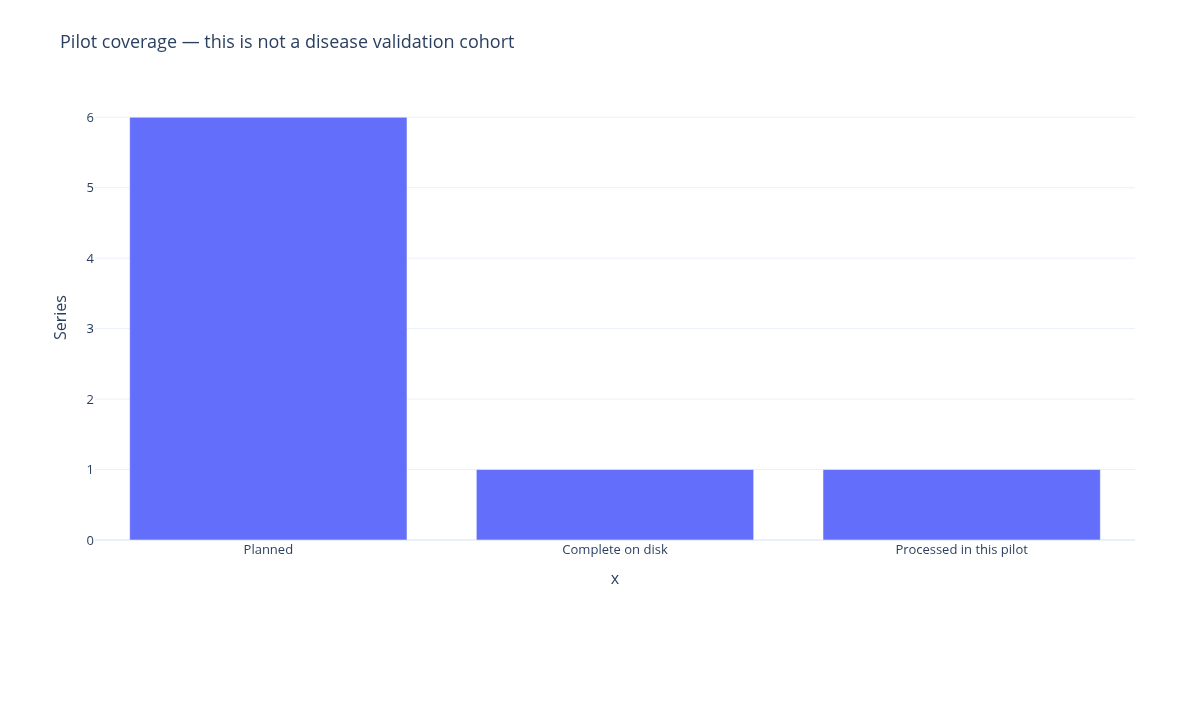

In [3]:
figure = round2_figure(DIRECTORY, 1)
figure.show(renderer='plotly_mimetype')

## 02. Eight image families

Candidate counts include whole-view and center-window summaries. These are not anatomically segmented or clinically calibrated measurements.

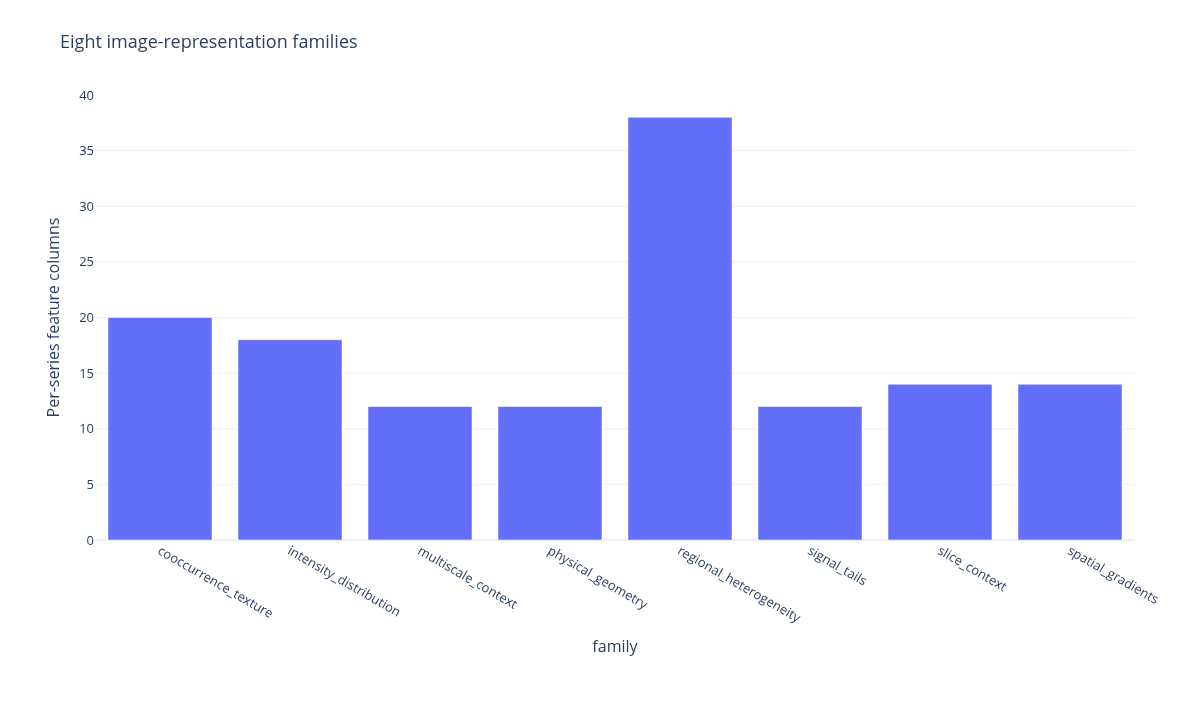

In [4]:
figure = round2_figure(DIRECTORY, 2)
figure.show(renderer='plotly_mimetype')

## 03. Signal distribution

MRI intensities are relative, normalized independently within the complete series. These are not quantitative T1/T2 or CT Hounsfield units.

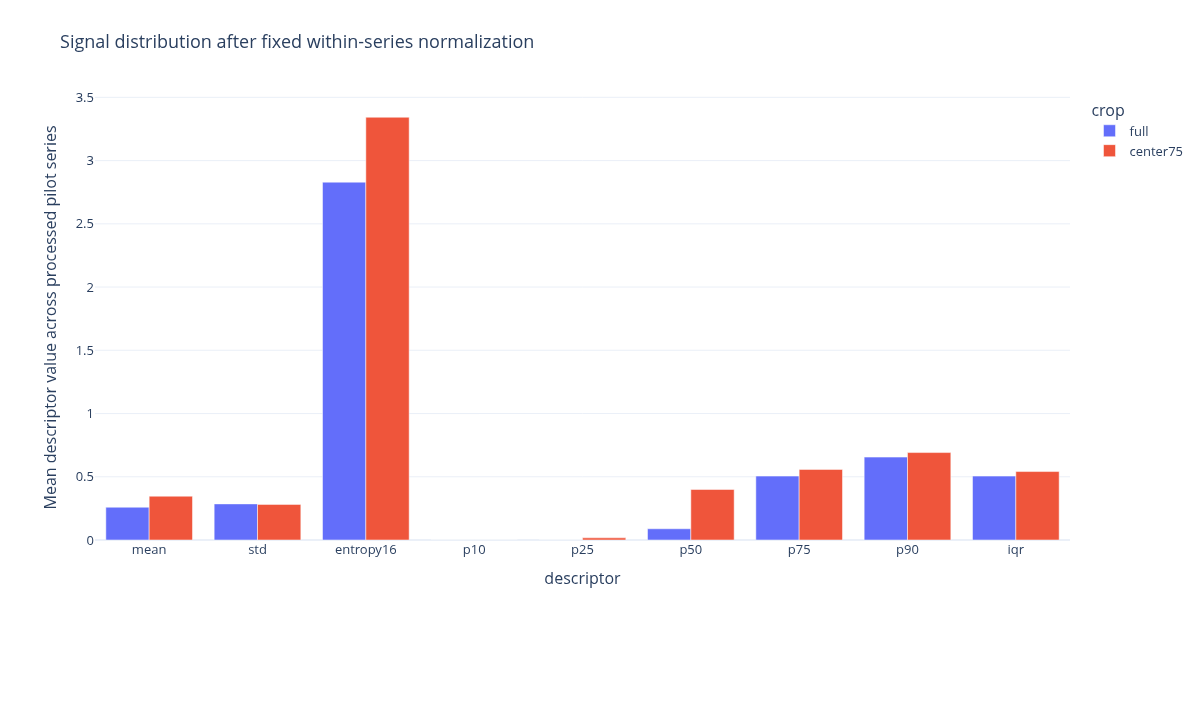

In [5]:
figure = round2_figure(DIRECTORY, 3)
figure.show(renderer='plotly_mimetype')

## 04. Field-of-view sensitivity

Center-minus-whole differences are image-relative representation changes. They are not validation-score deltas.

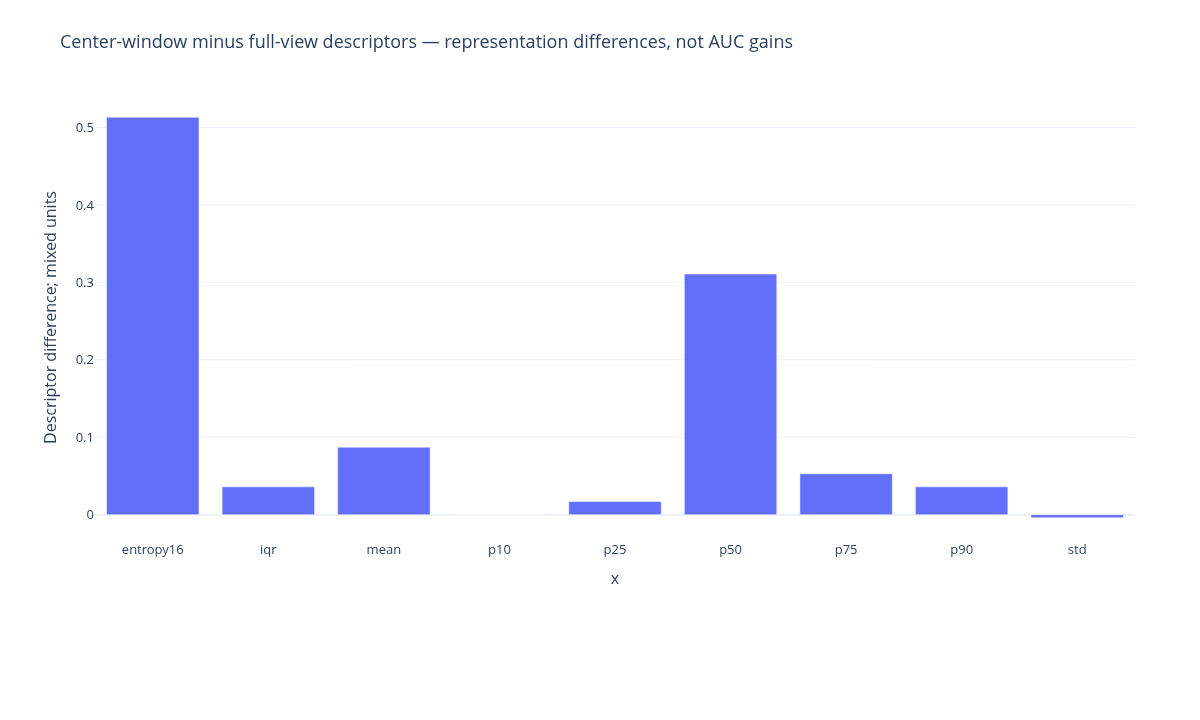

In [6]:
figure = round2_figure(DIRECTORY, 4)
figure.show(renderer='plotly_mimetype')

## 05. Signal tails

High/low-signal fractions use a fixed normalized scale. Brightness alone must not be labeled effusion, marrow edema, or another pathology.

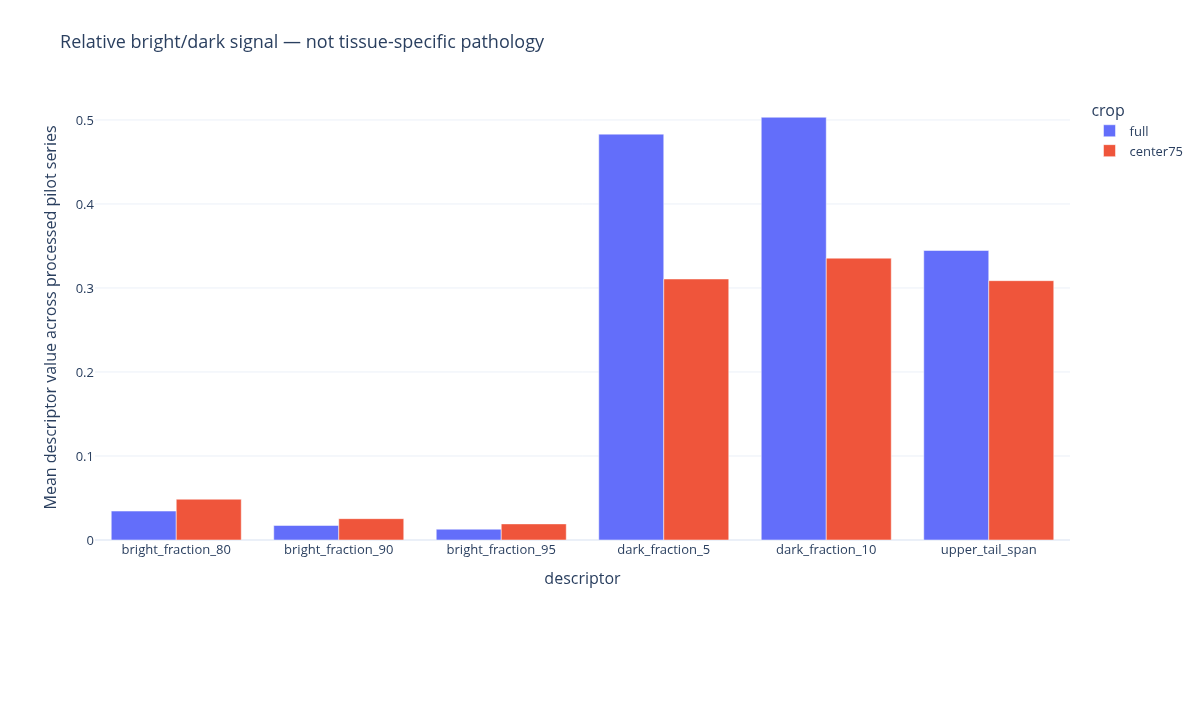

In [7]:
figure = round2_figure(DIRECTORY, 5)
figure.show(renderer='plotly_mimetype')

## 06. Spatial structure

Pixel-scale gradient descriptors retain acquisition dependence. Physical-resolution robustness remains an unresolved experiment.

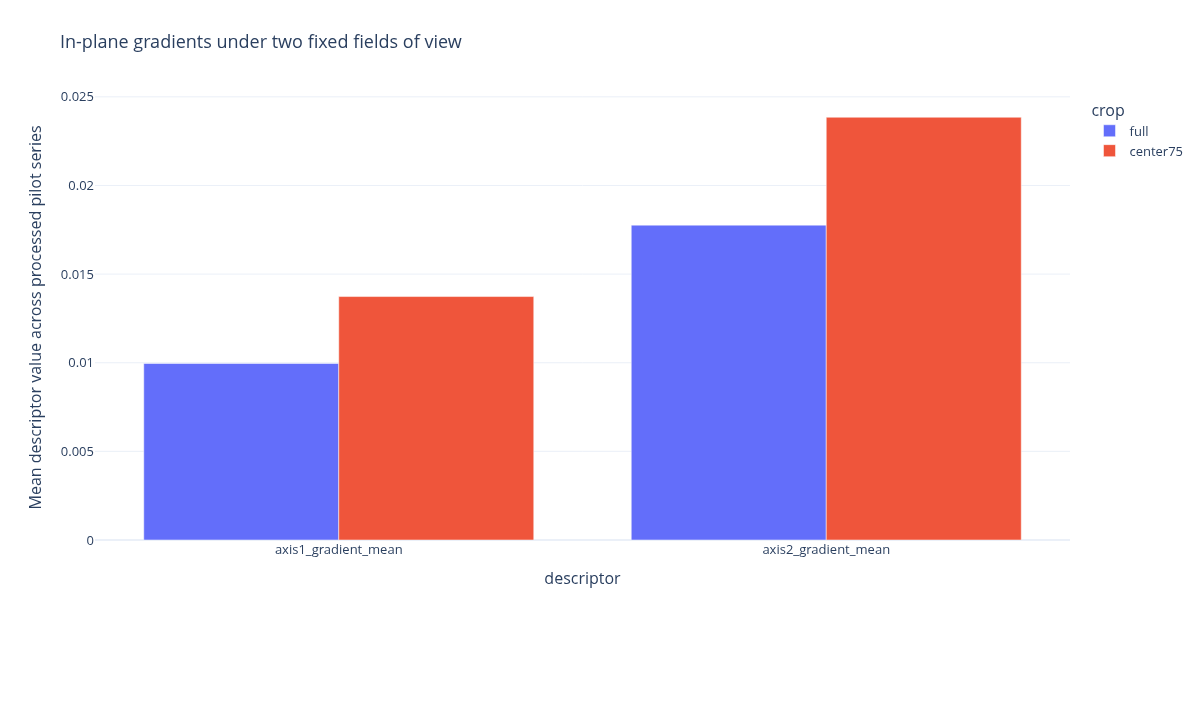

In [8]:
figure = round2_figure(DIRECTORY, 6)
figure.show(renderer='plotly_mimetype')

## 07. Texture offsets

Explicit 16-bin co-occurrence calculations use 1- and 2-pixel offsets. This is not an IBSI-certification claim.

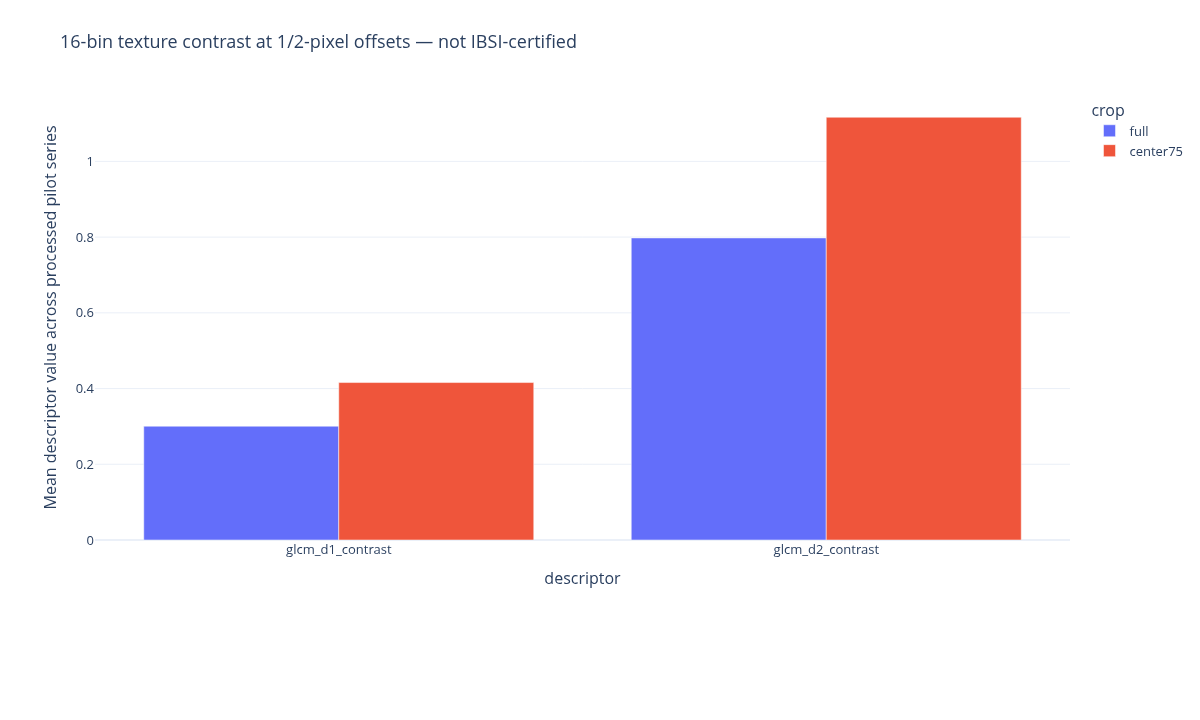

In [9]:
figure = round2_figure(DIRECTORY, 7)
figure.show(renderer='plotly_mimetype')

## 08. Regional heterogeneity

The grid is image-relative, not a map of ligament, meniscus, or cartilage. No MRI pixels or patient identifiers are displayed.

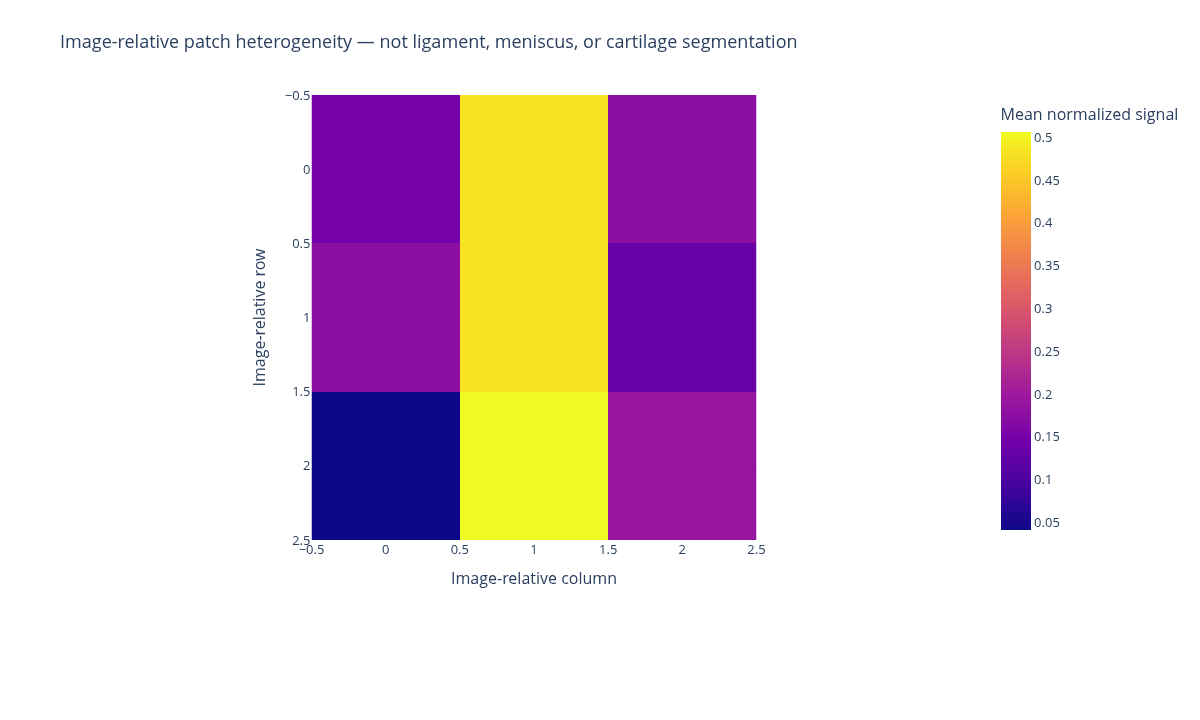

In [10]:
figure = round2_figure(DIRECTORY, 8)
figure.show(renderer='plotly_mimetype')

## 09. Slice context

Adjacent- and two-step slice differences rely on verified spatial order. This does not establish that all acquisitions are comparable.

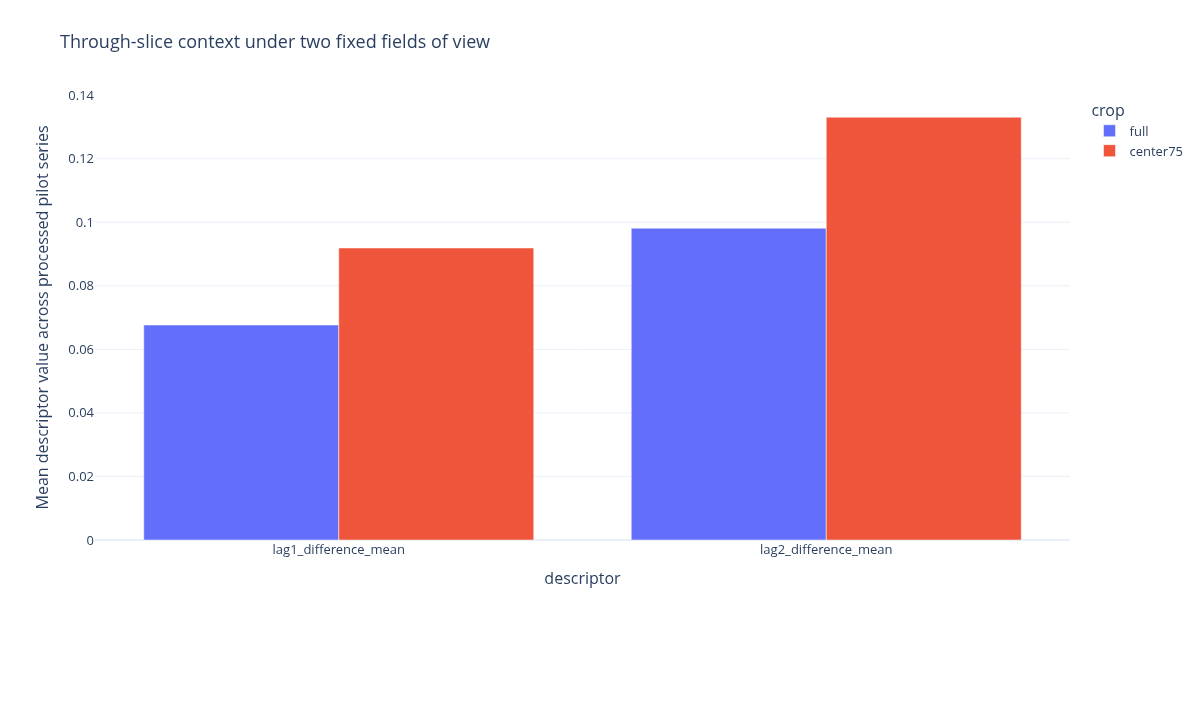

In [11]:
figure = round2_figure(DIRECTORY, 9)
figure.show(renderer='plotly_mimetype')

## 10. Multiscale context

Fixed average pooling probes coarse versus fine appearance; disease information could be lost as well as gained.

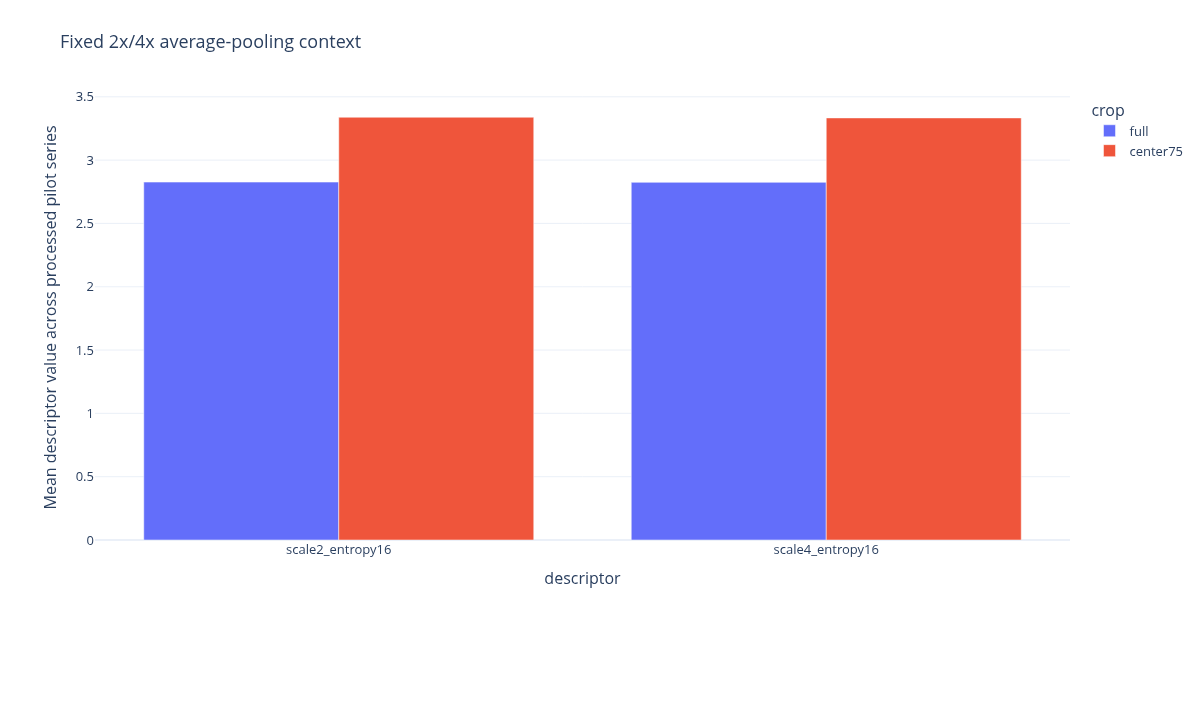

In [12]:
figure = round2_figure(DIRECTORY, 10)
figure.show(renderer='plotly_mimetype')

## 11. Physical geometry

Voxel spacing is reported in millimeters. Unexpected gaps, drift, orientation, or plane disagreement cause a stop rather than silent repair.

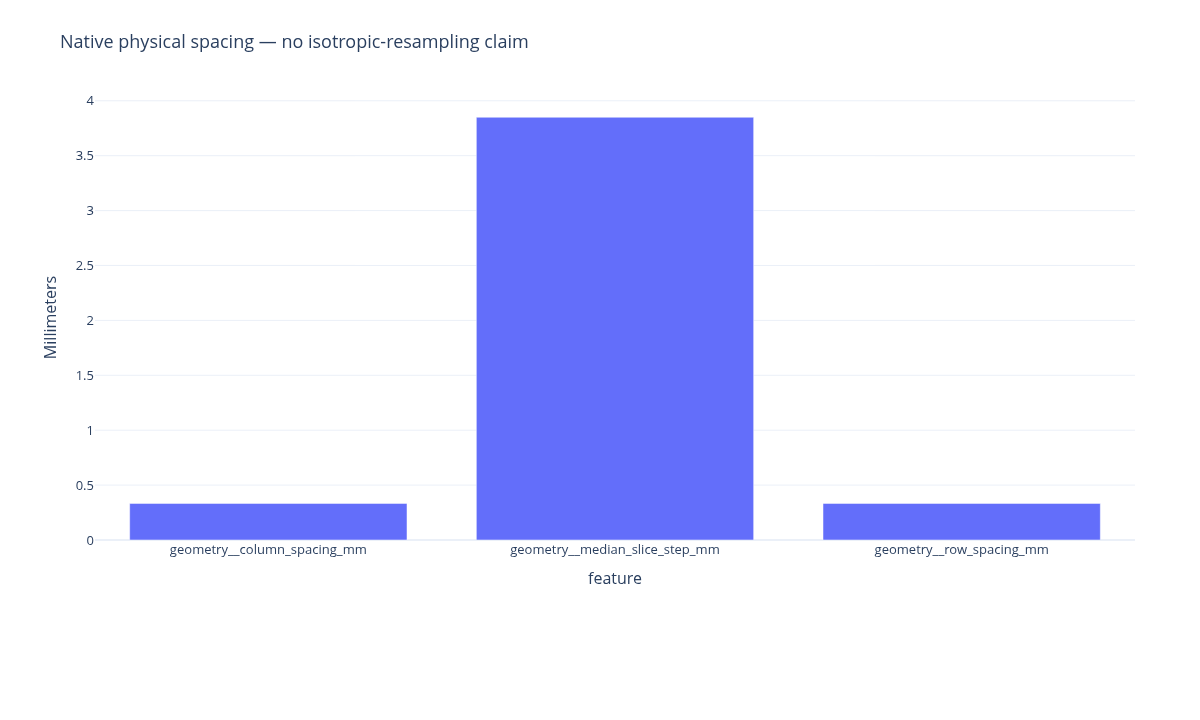

In [13]:
figure = round2_figure(DIRECTORY, 11)
figure.show(renderer='plotly_mimetype')

## 12. Checkpoint reuse

The second worker invocation should reuse the exact series checkpoint with zero recomputation. This is execution evidence, not model evidence.

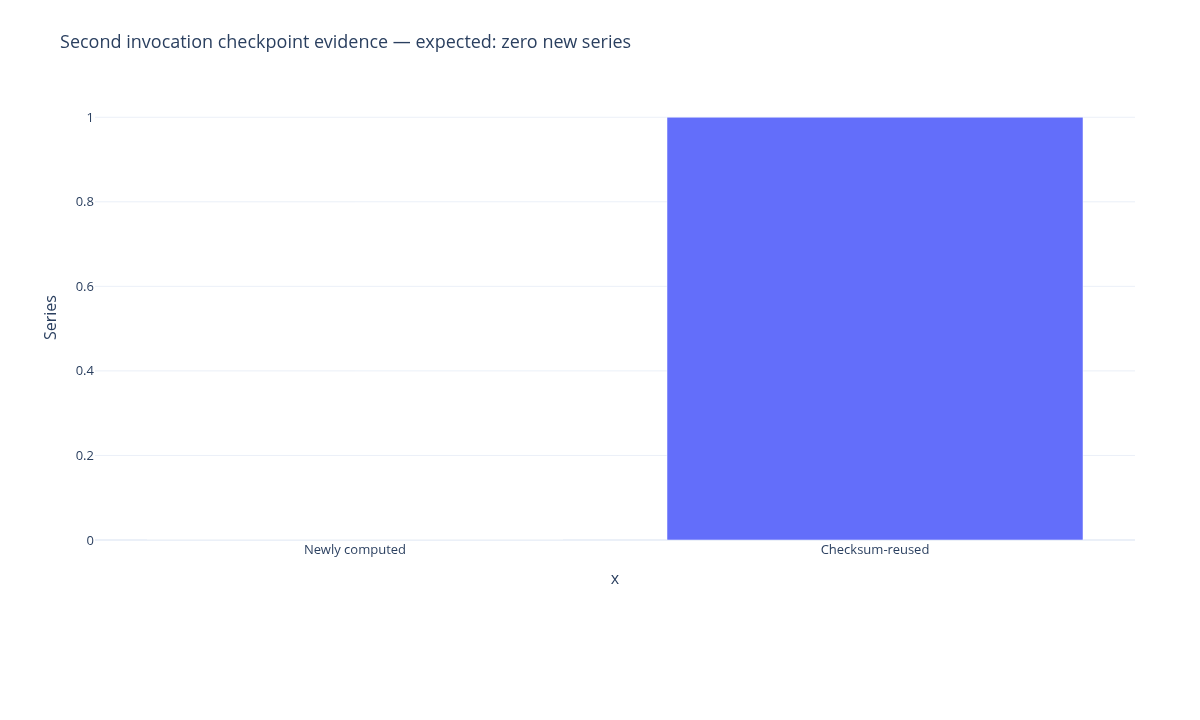

In [14]:
figure = round2_figure(DIRECTORY, 12)
figure.show(renderer='plotly_mimetype')

## Decision record and stop condition

Record all candidates as **not predictively evaluated**. No feature is promoted based on these charts. A future image-only baseline needs an approved supervision policy, patient/site leakage assessment, fixed folds, and controlled official-metric comparisons.

Save with **Ctrl+S**, close this tab, and reopen it. Verify the plots persist. Follow `NEXT_STEPS.md` for the allowlisted return ZIP; do not publish this working notebook to the public showcase.

In [15]:
print('R02_IMAGE_PILOT_COMPLETE')
print('Model fits: 0 | AUC improvement: not evaluated | Clinical validity: not established')

R02_IMAGE_PILOT_COMPLETE
Model fits: 0 | AUC improvement: not evaluated | Clinical validity: not established
